In [28]:
%pip install PyQt6
from pathlib import Path
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import mne

# Make MNE quieter
mne.set_log_level("WARNING")

# =========================
# CONFIG (edit these)
# =========================
DATA_RAW = Path("../data/raw")          # raw data base folder
DATA_ID = "ds004504"                   # e.g., 'ds004504' or 'ds006036'
BIDS_ROOT = DATA_RAW / DATA_ID         # expected BIDS dataset root
PARTICIPANTS_TSV = BIDS_ROOT / "participants.tsv"

# Label column name in participants.tsv (change if needed)
GROUP_COL = "Group"

# Extensions to look for (BIDS EEG/MEG commonly uses .edf .bdf .vhdr/.eeg .set .fif etc.)
EXTS = ("*.edf", "*.bdf", "*.set", "*.vhdr", "*.eeg", "*.fif")

print("BIDS_ROOT:", BIDS_ROOT.resolve())
print("PARTICIPANTS_TSV exists:", PARTICIPANTS_TSV.exists())


Note: you may need to restart the kernel to use updated packages.
BIDS_ROOT: C:\Users\ShalindaSilva\repo\detached-eeg\data\raw\ds004504
PARTICIPANTS_TSV exists: True


## 1) Labels: participants.tsv sanity checks

In [29]:
participants = pd.read_csv(PARTICIPANTS_TSV, sep="\t")
print("Columns:", participants.columns.tolist())
participants.head()

Columns: ['participant_id', 'Gender', 'Age', 'Group', 'MMSE']


,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


In [30]:
if GROUP_COL not in participants.columns:
    raise ValueError(f"GROUP_COL='{GROUP_COL}' not found. Available columns: {participants.columns.tolist()}")

participants[GROUP_COL] = participants[GROUP_COL].astype(str).str.strip()

print("Unique labels:", sorted(participants[GROUP_COL].unique()))
print("\nCounts per label:\n", participants[GROUP_COL].value_counts(dropna=False))

missing = participants[participants[GROUP_COL].isna() | (participants[GROUP_COL].str.lower().isin(["nan", "none", ""]))]

print("\nRows with missing/empty labels:", len(missing))
missing.head()


Unique labels: ['A', 'C', 'F']

Counts per label:
 Group
A    36
C    29
F    23
Name: count, dtype: int64

Rows with missing/empty labels: 0


,participant_id,Gender,Age,Group,MMSE


In [31]:
label_map = dict(zip(participants["participant_id"], participants[GROUP_COL]))
label_names = sorted(set(label_map.values()))
label_to_int = {lab: i for i, lab in enumerate(label_names)}

print("label_names:", label_names)
print("label_to_int:", label_to_int)

label_names: ['A', 'C', 'F']
label_to_int: {'A': 0, 'C': 1, 'F': 2}


## 2) File discovery: what recordings exist?

In [32]:
files = []
for ext in EXTS:
    files.extend(BIDS_ROOT.rglob(ext))
files = sorted(set(files))

print("Total candidate data files:", len(files))
files[:10]

Total candidate data files: 88


[WindowsPath('../data/raw/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-002/eeg/sub-002_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-003/eeg/sub-003_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-004/eeg/sub-004_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-005/eeg/sub-005_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-006/eeg/sub-006_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-007/eeg/sub-007_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-008/eeg/sub-008_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-009/eeg/sub-009_task-eyesclosed_eeg.set'),
 WindowsPath('../data/raw/ds004504/sub-010/eeg/sub-010_task-eyesclosed_eeg.set')]

## 3) Per-subject inventory (files per subject)

In [33]:
sub_re = re.compile(r"(sub-[a-zA-Z0-9]+)")
by_sub = defaultdict(list)

for f in files:
    m = sub_re.search(str(f))
    if m:
        by_sub[m.group(1)].append(f)

print("Subjects with discovered files:", len(by_sub))

if len(by_sub) > 0:
    counts = sorted([len(v) for v in by_sub.values()])
    print("Files per subject: min/median/max =", counts[0], np.median(counts), counts[-1])

# show a few subjects
for i, (sub, flist) in enumerate(list(by_sub.items())[:5]):
    print(f"\n{sub} -> {len(flist)} files")
    for f in flist[:5]:
        print("  ", f.relative_to(BIDS_ROOT))


Subjects with discovered files: 88
Files per subject: min/median/max = 1 1.0 1

sub-001 -> 1 files
   sub-001\eeg\sub-001_task-eyesclosed_eeg.set

sub-002 -> 1 files
   sub-002\eeg\sub-002_task-eyesclosed_eeg.set

sub-003 -> 1 files
   sub-003\eeg\sub-003_task-eyesclosed_eeg.set

sub-004 -> 1 files
   sub-004\eeg\sub-004_task-eyesclosed_eeg.set

sub-005 -> 1 files
   sub-005\eeg\sub-005_task-eyesclosed_eeg.set


## 4) Cross-check: subjects with files vs subjects with labels

In [34]:
subjects_in_files = sorted(by_sub.keys())
subjects_in_labels = sorted(label_map.keys())

set_files = set(subjects_in_files)
set_labels = set(subjects_in_labels)

print("Subjects (files):", len(set_files))
print("Subjects (labels):", len(set_labels))
print("Subjects with files but no label:", len(set_files - set_labels))
print("Subjects with label but no files:", len(set_labels - set_files))

# show examples
print("\nExamples: files but no label:", list(sorted(set_files - set_labels))[:10])
print("Examples: label but no files:", list(sorted(set_labels - set_files))[:10])


Subjects (files): 88
Subjects (labels): 88
Subjects with files but no label: 0
Subjects with label but no files: 0

Examples: files but no label: []
Examples: label but no files: []


## 5) Read a sample of recordings: sampling rate, channels, duration

In [35]:
def safe_read_raw(fpath: Path):
    """Attempt to read many EEG/MEG file types with MNE.
    Notes:
      - .vhdr is BrainVision header; reading it should pull the .eeg/.vmrk alongside.
      - .set is EEGLAB; can be slower.
    """
    return mne.io.read_raw(fpath, preload=False, verbose="ERROR")

def summarize_raw(fpath: Path):
    raw = safe_read_raw(fpath)
    sfreq = float(raw.info["sfreq"])
    n_ch = int(raw.info["nchan"])
    dur_sec = raw.n_times / sfreq
    ch_types = Counter(raw.get_channel_types())
    # Keep a short signature for channel names
    ch_name_sample = raw.ch_names[:10]
    return {
        "file": str(fpath.relative_to(BIDS_ROOT)),
        "sfreq": sfreq,
        "n_channels": n_ch,
        "duration_min": dur_sec / 60.0,
        "ch_types": dict(ch_types),
        "ch_names_first10": ch_name_sample,
    }

# Adjust sample size for speed
SAMPLE_N = min(20, len(files))
sample_files = files[:SAMPLE_N]

summaries = []
errors = []
for f in sample_files:
    try:
        summaries.append(summarize_raw(f))
    except Exception as e:
        errors.append((str(f.relative_to(BIDS_ROOT)), repr(e)))

print("Summarized:", len(summaries), "files")
print("Errors:", len(errors))
if errors:
    print("\nFirst 5 errors:")
    for item in errors[:5]:
        print(item[0], "->", item[1])

df_summary = pd.DataFrame(summaries)
df_summary.head()


Summarized: 20 files
Errors: 0


,file,sfreq,n_channels,duration_min,ch_types,ch_names_first10
0,sub-001\eeg\sub-001_task-eyesclosed_eeg.set,500.0,19,9.996667,{'eeg': 19},"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2]"
1,sub-002\eeg\sub-002_task-eyesclosed_eeg.set,500.0,19,13.218333,{'eeg': 19},"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2]"
2,sub-003\eeg\sub-003_task-eyesclosed_eeg.set,500.0,19,5.118333,{'eeg': 19},"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2]"
3,sub-004\eeg\sub-004_task-eyesclosed_eeg.set,500.0,19,11.785000,{'eeg': 19},"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2]"
4,sub-005\eeg\sub-005_task-eyesclosed_eeg.set,500.0,19,13.401667,{'eeg': 19},"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2]"


In [36]:
if len(summaries) == 0:
    raise RuntimeError("No files could be read. Check file discovery and supported formats.")

print("Sampling rates found:", sorted(df_summary["sfreq"].unique().tolist()))
print("Channel counts found:", sorted(df_summary["n_channels"].unique().tolist()))
print("Duration (min): min/median/max =",
      df_summary["duration_min"].min(),
      float(df_summary["duration_min"].median()),
      df_summary["duration_min"].max()
)

df_summary[["file", "sfreq", "n_channels", "duration_min"]].sort_values("duration_min", ascending=False).head(10)


Sampling rates found: [500.0]
Channel counts found: [19]
Duration (min): min/median/max = 5.118333333333334 13.701666666666668 21.51833333333333


,file,sfreq,n_channels,duration_min
9,sub-010\eeg\sub-010_task-eyesclosed_eeg.set,500.0,19,21.518333
15,sub-016\eeg\sub-016_task-eyesclosed_eeg.set,500.0,19,16.418333
13,sub-014\eeg\sub-014_task-eyesclosed_eeg.set,500.0,19,15.753333
18,sub-019\eeg\sub-019_task-eyesclosed_eeg.set,500.0,19,15.338333
14,sub-015\eeg\sub-015_task-eyesclosed_eeg.set,500.0,19,15.168333
11,sub-012\eeg\sub-012_task-eyesclosed_eeg.set,500.0,19,14.971667
19,sub-020\eeg\sub-020_task-eyesclosed_eeg.set,500.0,19,14.488333
17,sub-018\eeg\sub-018_task-eyesclosed_eeg.set,500.0,19,14.118333
16,sub-017\eeg\sub-017_task-eyesclosed_eeg.set,500.0,19,14.118333
12,sub-013\eeg\sub-013_task-eyesclosed_eeg.set,500.0,19,14.001667


## 6) Channel-name consistency

In [37]:
def get_channel_set(fpath: Path):
    raw = safe_read_raw(fpath)
    # Keep only data channels (exclude stim if present)
    picks = mne.pick_types(raw.info, eeg=True, meg=True, stim=False, eog=False, ecg=False, misc=False)
    chs = [raw.ch_names[i] for i in picks] if len(picks) else raw.ch_names
    return set(chs)

# Use the same sample_files (or increase SAMPLE_N above)
chan_sets = []
chan_errors = []
for f in sample_files:
    try:
        chan_sets.append((str(f.relative_to(BIDS_ROOT)), get_channel_set(f)))
    except Exception as e:
        chan_errors.append((str(f.relative_to(BIDS_ROOT)), repr(e)))

print("Channel-set computed for:", len(chan_sets), "files")
if chan_errors:
    print("Channel-set errors:", len(chan_errors))
    for item in chan_errors[:3]:
        print(item[0], "->", item[1])

# Intersection / union over sample
all_sets = [s for _, s in chan_sets]
intersection = set.intersection(*all_sets) if all_sets else set()
union = set.union(*all_sets) if all_sets else set()

print("Sample channel intersection size:", len(intersection))
print("Sample channel union size:", len(union))

# Show a few channels
print("\nIntersection (first 20):", sorted(list(intersection))[:20])
print("Union (first 20):", sorted(list(union))[:20])


Channel-set computed for: 20 files
Sample channel intersection size: 19
Sample channel union size: 19

Intersection (first 20): ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'Pz', 'T3', 'T4', 'T5', 'T6']
Union (first 20): ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'Pz', 'T3', 'T4', 'T5', 'T6']


In [38]:
# How different are files from the intersection?
diff_stats = []
for fname, chset in chan_sets:
    missing = sorted(list(intersection - chset))
    extra = sorted(list(chset - intersection))
    diff_stats.append({
        "file": fname,
        "missing_from_intersection": len(missing),
        "extra_vs_intersection": len(extra)
    })

df_diff = pd.DataFrame(diff_stats).sort_values(["missing_from_intersection", "extra_vs_intersection"], ascending=False)
df_diff.head(10)


,file,missing_from_intersection,extra_vs_intersection
0,sub-001\eeg\sub-001_task-eyesclosed_eeg.set,0,0
1,sub-002\eeg\sub-002_task-eyesclosed_eeg.set,0,0
2,sub-003\eeg\sub-003_task-eyesclosed_eeg.set,0,0
3,sub-004\eeg\sub-004_task-eyesclosed_eeg.set,0,0
4,sub-005\eeg\sub-005_task-eyesclosed_eeg.set,0,0
5,sub-006\eeg\sub-006_task-eyesclosed_eeg.set,0,0
6,sub-007\eeg\sub-007_task-eyesclosed_eeg.set,0,0
7,sub-008\eeg\sub-008_task-eyesclosed_eeg.set,0,0
8,sub-009\eeg\sub-009_task-eyesclosed_eeg.set,0,0
9,sub-010\eeg\sub-010_task-eyesclosed_eeg.set,0,0


## 8) Class balance among subjects that actually have files

In [39]:
# Subjects that have at least one discovered file
subs_with_files = sorted(by_sub.keys())

# Keep only those that also exist in label_map
subs_usable = [s for s in subs_with_files if s in label_map]

labels_usable = [label_map[s] for s in subs_usable]
counts = Counter(labels_usable)

print("Usable subjects (have file + label):", len(subs_usable))
print("Counts by label among usable subjects:")
for lab, c in sorted(counts.items(), key=lambda x: (-x[1], x[0])):
    print(f"  {lab}: {c}")


Usable subjects (have file + label): 88
Counts by label among usable subjects:
  A: 36
  C: 29
  F: 23


C:\Users\ShalindaSilva\AppData\Local\Temp\ipykernel_29316\3091424433.py:13: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_6036 = mne.io.read_raw_eeglab(path_ds6036, preload=True)


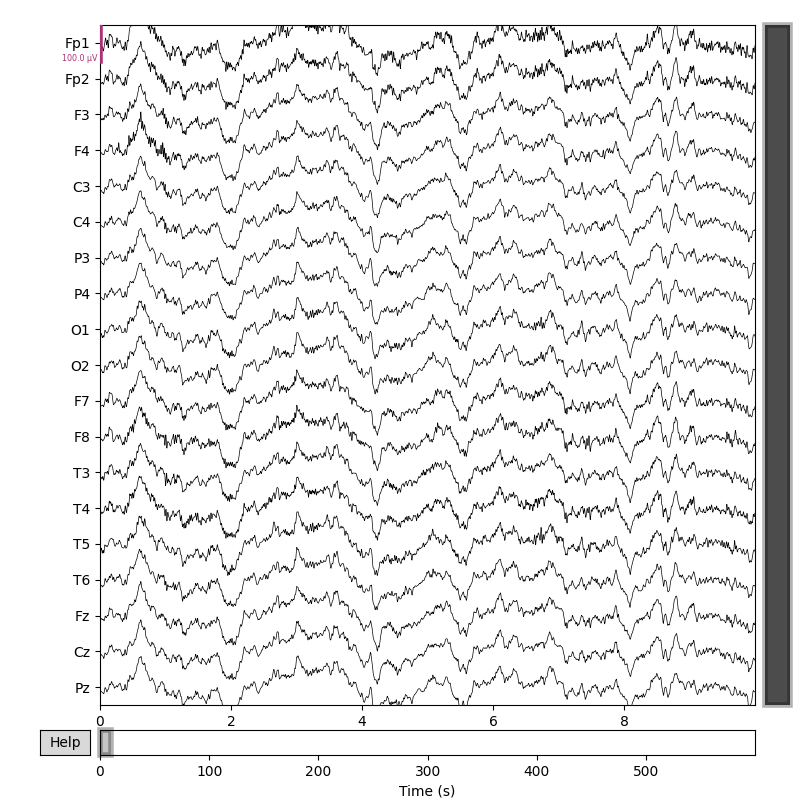

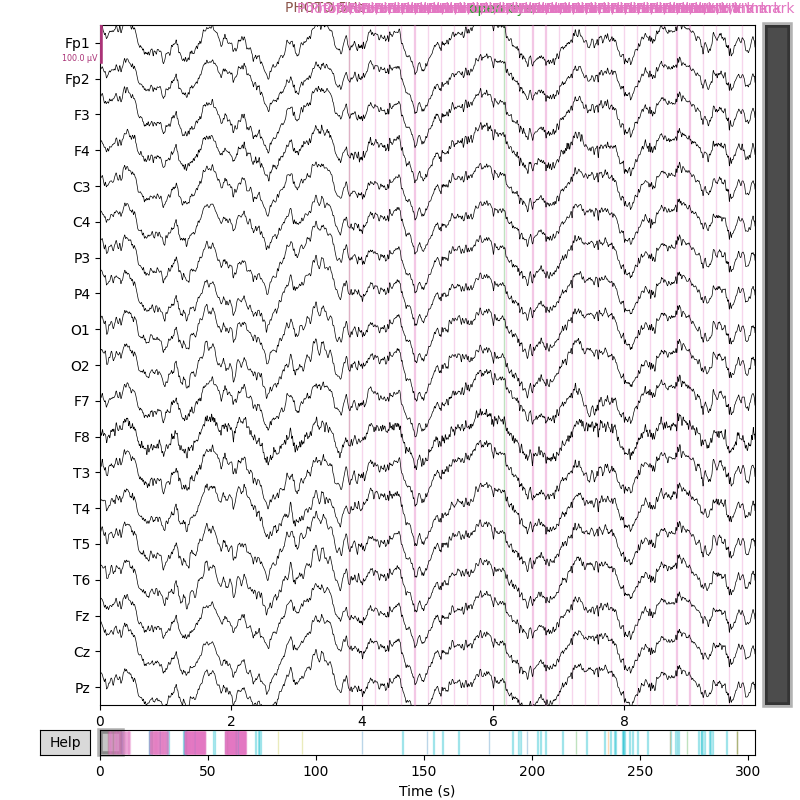

In [40]:
import mne
import matplotlib.pyplot as plt

# 1. Use the interactive 'widget' backend instead of inline/qt
%matplotlib widget

# Relative paths for both subjects
path_ds4504 = r'../data/processed/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set'
path_ds6036 = r'../data/processed/ds006036/sub-001/eeg/sub-001_task-photomark_eeg.set'

# Load the data
raw_4504 = mne.io.read_raw_eeglab(path_ds4504, preload=True)
raw_6036 = mne.io.read_raw_eeglab(path_ds6036, preload=True)

# Lock scale to make visual comparison perfect
shared_scale = dict(eeg=50e-6)

# Time duration to show per 'page'. E.g., setting it to 10 loads the first 
# 10 seconds, but you can scroll forward to see the rest of the file
show_duration = 10 
show_channels = min(len(raw_4504.ch_names), len(raw_6036.ch_names))

# Create the interactive plots!
# Note: In widget mode, we omit plt.show() since Jupyter handles rendering automatically
fig1 = raw_4504.plot(duration=show_duration, n_channels=show_channels, 
                     scalings=shared_scale, title='ds004504 - Subject 1 (Eyes Closed)')

fig2 = raw_6036.plot(duration=show_duration, n_channels=show_channels, 
                     scalings=shared_scale, title='ds006036 - Subject 1 (Photomark)')
